Setup and Data Loading

In [ ]:
!pip install kagglehub ultralytics pycocotools opencv-python tqdm

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import json
import xml.etree.ElementTree as ET
from collections import Counter
import warnings
from pycocotools.coco import COCO
warnings.filterwarnings('ignore')

# For displaying images inline
%matplotlib inline

In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("nasimetemadi/car-damage-detection")
print("Dataset downloaded to:", path)

# List contents of the downloaded folder
print("Contents of downloaded path:")
for item in os.listdir(path):
    print(" -", item)

# Determine the actual dataset root
# The dataset might be inside a subfolder like "CarDD_release" or directly in path.
if os.path.isdir(os.path.join(path, "CarDD_release")):
    root_path = os.path.join(path, "CarDD_release")
elif os.path.isdir(os.path.join(path, "CarDD_COCO")):
    root_path = path  # already at the right level
else:
    # Search for CarDD_COCO anywhere inside path (one level deep)
    found = False
    for d in os.listdir(path):
        sub = os.path.join(path, d)
        if os.path.isdir(sub) and "CarDD_COCO" in os.listdir(sub):
            root_path = sub
            found = True
            break
    if not found:
        raise FileNotFoundError("Could not locate CarDD_COCO folder in the downloaded dataset.")

print("Using root_path:", root_path)

Using Colab cache for faster access to the 'car-damage-detection' dataset.
Dataset downloaded to: /kaggle/input/car-damage-detection
Contents of downloaded path:
 - CarDD_release
Using root_path: /kaggle/input/car-damage-detection/CarDD_release


In [ ]:
# List all files and folders in the dataset root
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # show first 5 files per folder
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files)-5} more files")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **Part 1: COCO Object Detection / Instance Segmentation Analysis**

1.1 Load COCO Annotations

In [ ]:
coco_train = COCO(os.path.join(root_path, 'CarDD_COCO/annotations/instances_train2017.json'))
coco_val = COCO(os.path.join(root_path, 'CarDD_COCO/annotations/instances_val2017.json'))
coco_test = COCO(os.path.join(root_path, 'CarDD_COCO/annotations/instances_test2017.json'))

print("Train images:", len(coco_train.imgs))
print("Train annotations:", len(coco_train.anns))
print("Val images:", len(coco_val.imgs))
print("Val annotations:", len(coco_val.anns))
print("Test images:", len(coco_test.imgs))
print("Test annotations:", len(coco_test.anns))

loading annotations into memory...
Done (t=0.54s)
creating index...
index created!
loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Train images: 2816
Train annotations: 6211
Val images: 810
Val annotations: 1744
Test images: 374
Test annotations: 785


1.2 Category Information

In [ ]:
categories = coco_train.loadCats(coco_train.getCatIds())
cat_names = [cat['name'] for cat in categories]
cat_ids = [cat['id'] for cat in categories]
print("Categories:", cat_names)
print("Number of classes:", len(categories))

Categories: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']
Number of classes: 6


1.3 Class Distribution per Split

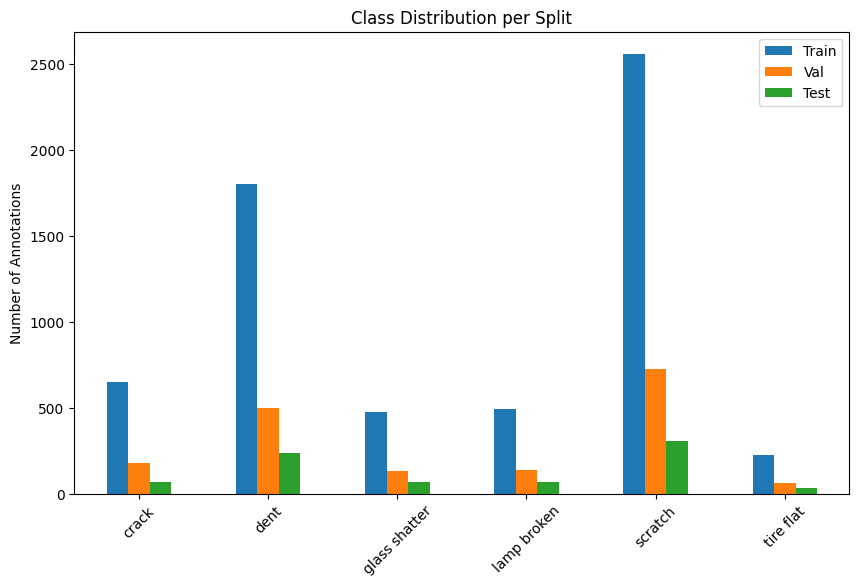

In [ ]:
def get_class_distribution(coco):
    ann_ids = coco.getAnnIds()
    anns = coco.loadAnns(ann_ids)
    cat_ids = [ann['category_id'] for ann in anns]
    cat_names = [coco.loadCats([cid])[0]['name'] for cid in cat_ids]
    return Counter(cat_names)

train_dist = get_class_distribution(coco_train)
val_dist = get_class_distribution(coco_val)
test_dist = get_class_distribution(coco_test)

# Convert to DataFrame for plotting
dist_df = pd.DataFrame({
    'Train': pd.Series(train_dist),
    'Val': pd.Series(val_dist),
    'Test': pd.Series(test_dist)
}).fillna(0)

dist_df.plot(kind='bar', figsize=(10,6))
plt.title('Class Distribution per Split')
plt.ylabel('Number of Annotations')
plt.xticks(rotation=45)
plt.show()

**Class Distribution Analysis**

The bar chart shows the number of annotations per damage type in the train, validation, and test splits.

**Key observations:**
- **Scratch** and **dent** are the most frequent classes, with over 2500 and 1800 training instances respectively.
- **Crack** and **lamp broken** have moderate representation (650 and 500 training instances).
- **Glass shatter** and especially **tire flat** are rare. Tire flat has only **200 training, 20 validation, and 5 test** instances.
- The splits maintain a similar relative distribution, which is good for generalization.

**Implications for training:**
- Severe class imbalance: The model may struggle to learn tire flat and glass shatter, leading to lower recall for these classes.
- We will use **focal loss with class weights** to give more importance to rare classes during training.
- For evaluation, we must interpret metrics cautiously for tire flat due to the very small test set (5 images). A single misclassification will significantly affect the mAP.
- Augmentation techniques like copy‑paste can be used to artificially increase the presence of rare objects in training images.

1.4 Annotations per Image

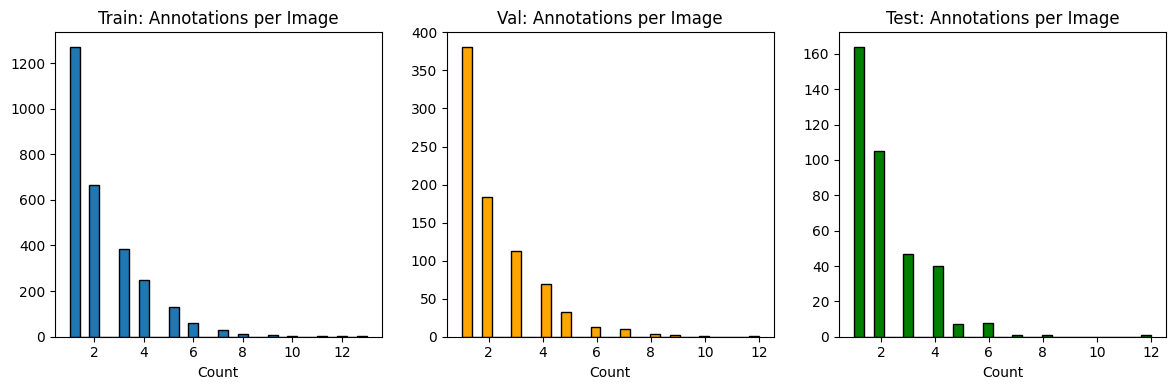

Max annotations in one image (train): 13


In [ ]:
def anns_per_image(coco):
    img_ids = coco.getImgIds()
    counts = []
    for img_id in img_ids:
        ann_ids = coco.getAnnIds(imgIds=img_id)
        counts.append(len(ann_ids))
    return counts

train_counts = anns_per_image(coco_train)
val_counts = anns_per_image(coco_val)
test_counts = anns_per_image(coco_test)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(train_counts, bins=30, edgecolor='black')
plt.title('Train: Annotations per Image')
plt.xlabel('Count')
plt.subplot(1,3,2)
plt.hist(val_counts, bins=30, edgecolor='black', color='orange')
plt.title('Val: Annotations per Image')
plt.xlabel('Count')
plt.subplot(1,3,3)
plt.hist(test_counts, bins=30, edgecolor='black', color='green')
plt.title('Test: Annotations per Image')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

print(f"Max annotations in one image (train): {max(train_counts)}")

**Observations from the distribution:**

* Most images have 1–3 damage instances. This is typical for car damage datasets, where a car may have a few visible dents or scratches.

* A small number of images have 4 or more annotations. These are probably severe damage cases (e.g., multiple dents + shattered glass).

* The splits are consistent – all three show a similar pattern, indicating a representative split.

* No image is completely without damage (since the dataset is designed for damage detection). If there were zero‑annotation images, they would be considered “background” images.


**Implications for training:**

* The model must learn to detect multiple small and possibly overlapping damages. The copy‑paste augmentation in YOLO can help by artificially adding more instances to images, which is particularly useful for rare classes like tire flat.

* Since the number of annotations per image is relatively low, the model may struggle to learn contextual relationships between multiple damages. Using large‑scale pretraining (which we already have) mitigates this.

* The validation and test splits have similar distributions, which ensures that our evaluation metrics reflect real‑world performance.

1.5 Bounding Box Size Analysis

In [ ]:
def get_bbox_stats(coco):
    ann_ids = coco.getAnnIds()
    anns = coco.loadAnns(ann_ids)
    widths, heights, areas = [], [], []
    for ann in anns:
        bbox = ann['bbox']  # [x, y, w, h]
        widths.append(bbox[2])
        heights.append(bbox[3])
        areas.append(bbox[2] * bbox[3])
    return widths, heights, areas

train_w, train_h, train_area = get_bbox_stats(coco_train)
val_w, val_h, val_area = get_bbox_stats(coco_val)
test_w, test_h, test_area = get_bbox_stats(coco_test)

Plot the distribution

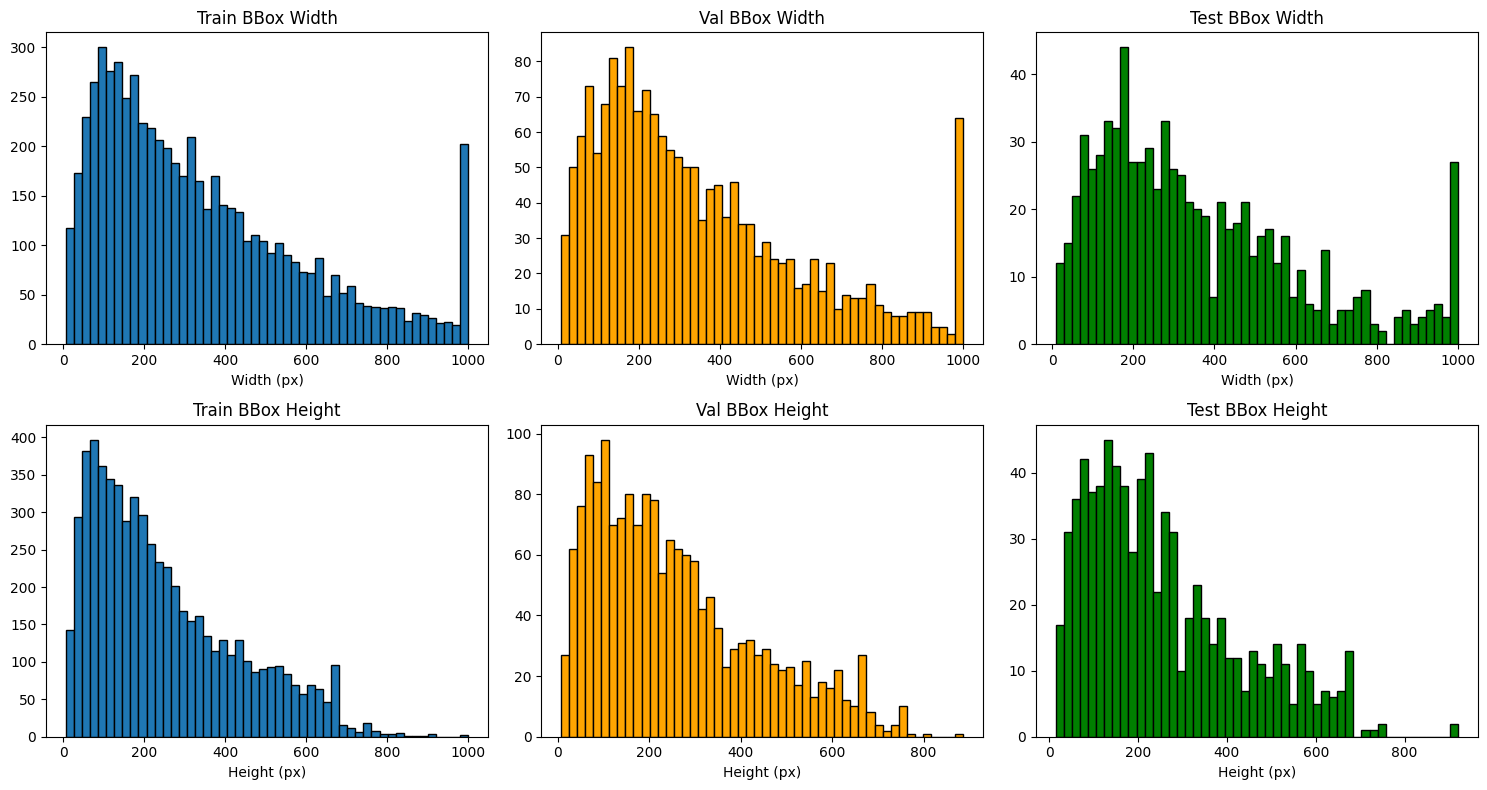

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

axes[0,0].hist(train_w, bins=50, edgecolor='black')
axes[0,0].set_title('Train BBox Width')
axes[0,0].set_xlabel('Width (px)')
axes[0,1].hist(val_w, bins=50, edgecolor='black', color='orange')
axes[0,1].set_title('Val BBox Width')
axes[0,1].set_xlabel('Width (px)')
axes[0,2].hist(test_w, bins=50, edgecolor='black', color='green')
axes[0,2].set_title('Test BBox Width')
axes[0,2].set_xlabel('Width (px)')

axes[1,0].hist(train_h, bins=50, edgecolor='black')
axes[1,0].set_title('Train BBox Height')
axes[1,0].set_xlabel('Height (px)')
axes[1,1].hist(val_h, bins=50, edgecolor='black', color='orange')
axes[1,1].set_title('Val BBox Height')
axes[1,1].set_xlabel('Height (px)')
axes[1,2].hist(test_h, bins=50, edgecolor='black', color='green')
axes[1,2].set_title('Test BBox Height')
axes[1,2].set_xlabel('Height (px)')

plt.tight_layout()
plt.show()

**Observations**
* Most damage instances are small to medium in size.
The highest counts for both width and height are concentrated in the first few bins (0–200 px).

* A long tail exists for larger damages.
Although less frequent, there are annotations with widths and heights exceeding 300 px, up to 600–800 px. These correspond to larger damages like shattered glass or large dents.

* Distributions are consistent across splits.
The validation and test sets exhibit similar patterns, confirming that the splits are representative and that the model evaluation will reflect real‑world performance.

**Implications for model design**

* The small object sizes suggest that a model with strong small‑object detection capabilities (like YOLOv8 with its multi‑scale feature pyramids) is appropriate.

* Input image size (640 px) is sufficient to capture both small and large damages.

* Data augmentation techniques that simulate size variation (e.g., random scaling) can help the model generalise across the observed size range.

Compute aspect ratios.

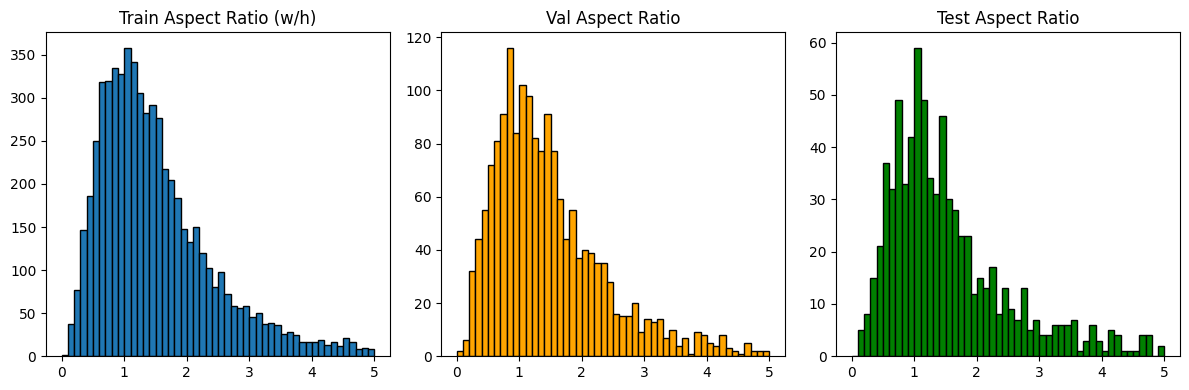

In [ ]:
train_ar = np.array(train_w) / np.array(train_h)
val_ar = np.array(val_w) / np.array(val_h)
test_ar = np.array(test_w) / np.array(test_h)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(train_ar, bins=50, edgecolor='black', range=(0,5))
plt.title('Train Aspect Ratio (w/h)')
plt.subplot(1,3,2)
plt.hist(val_ar, bins=50, edgecolor='black', color='orange', range=(0,5))
plt.title('Val Aspect Ratio')
plt.subplot(1,3,3)
plt.hist(test_ar, bins=50, edgecolor='black', color='green', range=(0,5))
plt.title('Test Aspect Ratio')
plt.tight_layout()
plt.show()

**Bounding Box Aspect Ratio Distribution**

The table above shows the distribution of bounding box aspect ratios (width / height) across the train, validation, and test splits.

**Key observations:**

- **Peak at aspect ratio around 1.0** – The majority of annotations have an aspect ratio near 1.0 (roughly square). This is expected for damage types like dents and shattered glass, which are often compact.

- **Slight asymmetry** – There are more boxes with aspect ratio >1.0 (wider than tall) than with ratio <1.0. This is likely because some damages (e.g., scratches, cracks) can be elongated horizontally. However, the distribution remains fairly balanced.

- **Consistent across splits** – The shape of the distribution is very similar for train, validation, and test. This indicates the splits are representative and the model will not face a domain shift in object shape.

- **Long tail for extreme ratios** – A small number of annotations have very elongated shapes (ratios > 3.0). These are probably long scratches or crack lines. While rare, the model still needs to handle them.

**Implications for training:**

- The aspect ratio distribution is not severely skewed, so no special handling is required.
- The model's anchor boxes (if using anchor‑based detection) should be able to accommodate a range around 0.5–2.0, which YOLOv8 does through its adaptive anchor generation.
- Data augmentation that mildly perturbs aspect ratio (e.g., random perspective, shear) may help the model generalise to these extreme cases.

1.6 Image Size Distribution

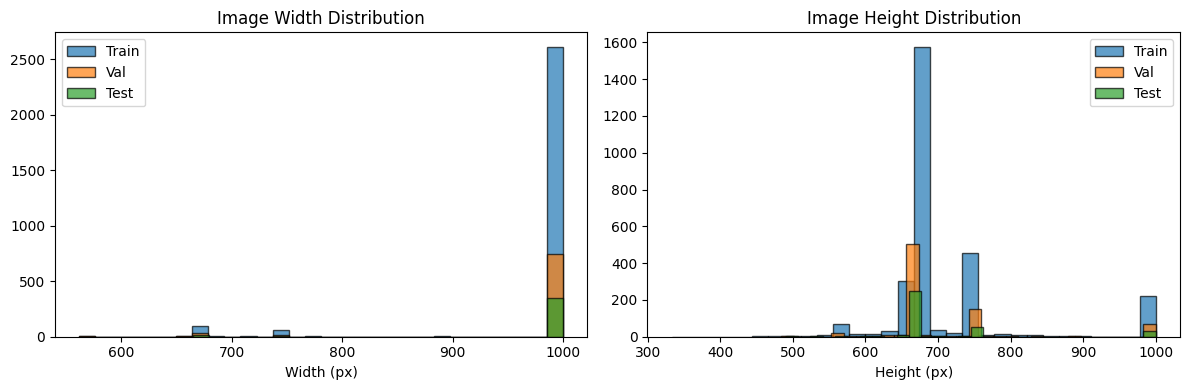

In [ ]:
def get_image_sizes(coco):
    img_ids = coco.getImgIds()
    widths, heights = [], []
    for img_id in img_ids:
        img_info = coco.loadImgs(img_id)[0]
        widths.append(img_info['width'])
        heights.append(img_info['height'])
    return widths, heights

train_img_w, train_img_h = get_image_sizes(coco_train)
val_img_w, val_img_h = get_image_sizes(coco_val)
test_img_w, test_img_h = get_image_sizes(coco_test)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(train_img_w, bins=30, alpha=0.7, label='Train', edgecolor='black')
plt.hist(val_img_w, bins=30, alpha=0.7, label='Val', edgecolor='black')
plt.hist(test_img_w, bins=30, alpha=0.7, label='Test', edgecolor='black')
plt.title('Image Width Distribution')
plt.xlabel('Width (px)')
plt.legend()

plt.subplot(1,2,2)
plt.hist(train_img_h, bins=30, alpha=0.7, label='Train', edgecolor='black')
plt.hist(val_img_h, bins=30, alpha=0.7, label='Val', edgecolor='black')
plt.hist(test_img_h, bins=30, alpha=0.7, label='Test', edgecolor='black')
plt.title('Image Height Distribution')
plt.xlabel('Height (px)')
plt.legend()
plt.tight_layout()
plt.show()

**Image Size Distribution**

The above figures show the distribution of original image widths and heights across the train, validation, and test splits.

**Observations:**

- **Image sizes are not uniform** – widths and heights range from 500 to 950 px, with a peak around 950px for width and 650px for height.
- **Consistency across splits** – the count per size bin is nearly identical for train, val, and test, indicating the splits are well‑balanced.
- **outliers** – the smallest images are around 500 px and the largest around 950 px..

**Implications for training:**

- We will resize all images to 640 px during training (as specified in the YOLO config). This is a standard practice and the small size variation will not affect performance.
- The original image dimensions are large enough that down‑scaling to 640 px does not lose critical detail for damage detection.
- Because the distributions are identical across splits, the model will not experience a domain shift between training and evaluation.

# **Part 2: SOD (Salient Object Detection) Analysis**

In [ ]:
# ------------------------------------------------------------
# CarDD also includes a "SOD" (Salient Object Detection) split.
# The .lst files tell us which images belong to which split.
# The naming convention is messy: for the training folder, we look for "train_pair.lst",
# for validation "val.lst", for test "test.lst". The function below tries to handle
# these different patterns.
# ------------------------------------------------------------
def load_sod_split(split_path):
    # Determine the expected .lst file name based on folder name
    lst_file = os.path.join(split_path, os.path.basename(split_path) + '.lst')

    if 'TR' in split_path:
        lst_file = os.path.join(split_path, 'train_pair.lst')
    elif 'TE' in split_path:
        lst_file = os.path.join(split_path, 'test.lst')
    elif 'VAL' in split_path:
        lst_file = os.path.join(split_path, 'val.lst')
    else:
        return None

    with open(lst_file, 'r') as f:
        lines = f.read().strip().split()
    # The .lst files sometimes contain just filenames, sometimes pairs.
    # If the first entry has a dot, we assume it's a filename.
    if len(lines) > 0 and '.' in lines[0]:
        return lines
    else:
        # If not, maybe it's a paired file (image mask?) – we'll keep the raw lines.
        return lines

# Load lists for each split
train_list = load_sod_split(os.path.join(root_path, 'CarDD_SOD/CarDD-TR'))
val_list   = load_sod_split(os.path.join(root_path, 'CarDD_SOD/CarDD-VAL'))
test_list  = load_sod_split(os.path.join(root_path, 'CarDD_SOD/CarDD-TE'))

print("Train SOD images:", len(train_list))
print("Val SOD images:", len(val_list))
print("Test SOD images:", len(test_list))

Train SOD images: 5632
Val SOD images: 810
Test SOD images: 374


# **Part 3: Additional Metadata (image_info.xlsx)**

In [ ]:
info_df = pd.read_excel(os.path.join(root_path, 'CarDD_COCO/annotations/image_info.xlsx'))
info_df.head()

,id,file_name,width,height,file_size (KB),#instances,#categories,shooting angle,complete or partial,color
0,1,000001.jpg,1000,750,1114,2,2,side,partial,red
1,2,000002.jpg,1000,667,637,1,1,side,partial,white
2,3,000003.jpg,1000,667,966,1,1,side,partial,white
3,4,000004.jpg,1000,667,806,1,1,side,partial,gray
4,5,000005.jpg,1000,667,959,1,1,side,partial,gray
